## Actividad de Histogramas y LUT

In [1]:
import numpy as np
import skimage
from skimage.io import imread
import matplotlib.pyplot as plt

En ejercicios pasados implementamos algunas transformaciones de niveles de intensidad en imágenes en escala de grises. En este ejercio, trabajaremos con una forma de implementar esto que se conoce como Look-up table.

**Por ejemplo:**

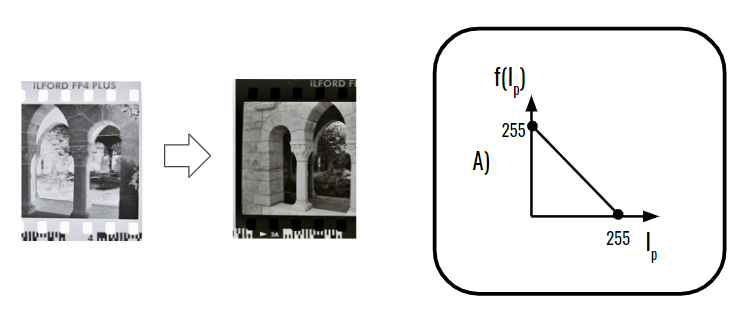

Esta transformación permite convertir una imagen de negativo->positivo (y viceversa). La ecuación que define está transformación se puede ver a continuación.

$I'_{x,y} = 255-I_{x,y}$

Cabe resaltar, que al aplicar esta transformación, el nivel de intensidad de cada pixel será reemplazado con el resultado de 255 menos el nivel de intensidad original.

Otra forma de realizar esta misma transformación de intensidad es usar un $LUT$ (lookup table), una suerte de diccionario, que mapea un valor de intensidad en la imagen al valor por el que será transformado. La ecuación a continuación muestra como es realizada la transformación usando un LUT.

$I'_{x,y} = LUT[I_{x,y}]$

Por ejemplo el diccionario (en una arreglo de numpy) para crear la transformación anterior (de negativo a positivo) sería así


In [2]:
LUT = 255-np.arange(256)
print(LUT)

[255 254 253 252 251 250 249 248 247 246 245 244 243 242 241 240 239 238
 237 236 235 234 233 232 231 230 229 228 227 226 225 224 223 222 221 220
 219 218 217 216 215 214 213 212 211 210 209 208 207 206 205 204 203 202
 201 200 199 198 197 196 195 194 193 192 191 190 189 188 187 186 185 184
 183 182 181 180 179 178 177 176 175 174 173 172 171 170 169 168 167 166
 165 164 163 162 161 160 159 158 157 156 155 154 153 152 151 150 149 148
 147 146 145 144 143 142 141 140 139 138 137 136 135 134 133 132 131 130
 129 128 127 126 125 124 123 122 121 120 119 118 117 116 115 114 113 112
 111 110 109 108 107 106 105 104 103 102 101 100  99  98  97  96  95  94
  93  92  91  90  89  88  87  86  85  84  83  82  81  80  79  78  77  76
  75  74  73  72  71  70  69  68  67  66  65  64  63  62  61  60  59  58
  57  56  55  54  53  52  51  50  49  48  47  46  45  44  43  42  41  40
  39  38  37  36  35  34  33  32  31  30  29  28  27  26  25  24  23  22
  21  20  19  18  17  16  15  14  13  12  11  10   

A continuación, se le solicita implementar un función que reciba una imagen en escala de grises y un arreglo de 256 (LUT - lookup table) tal que la imagen resultante sea transformada usando la regla $I'_{x,y} = LUT[I_{x,y}]$. Es decir, para cada pixel de la imagen (que puede tener un valor entre 0 y 255) se busca en la table LUT el valor por el que se reemplazará.

**Recomendación**: Usar una imagen intermedia (o auxiliar) para construir la respuesta en varios pasos.

### Creación del LUT y función de aplicación

Implemente la función a continuación

In [3]:
def aplicar(im, LUT):
    assert im.ndim == 2  #verificamos que sea una imagen en escala de grises
    assert LUT.shape==(256,) #verificamos que el arreglo

    ###### Implementar aquí ############
    im=LUT[im]

    ####################################
    return im


A continuación leeremos una imagen (y la transformamos a negativo)

In [4]:
!gdown 1P30B1qHtk-mZJudONuQp4axFbLWhLzqP

Downloading...
From: https://drive.google.com/uc?id=1P30B1qHtk-mZJudONuQp4axFbLWhLzqP
To: /content/IMG1.jpg
100% 116k/116k [00:00<00:00, 13.8MB/s]


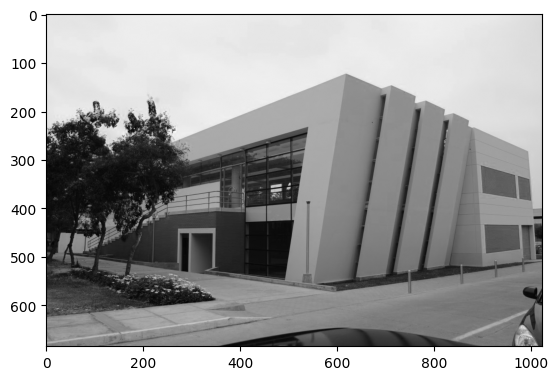

In [5]:
im = imread('IMG1.jpg')[:,:,0]
plt.imshow(im, cmap='gray')

y aplicaremos la transformación




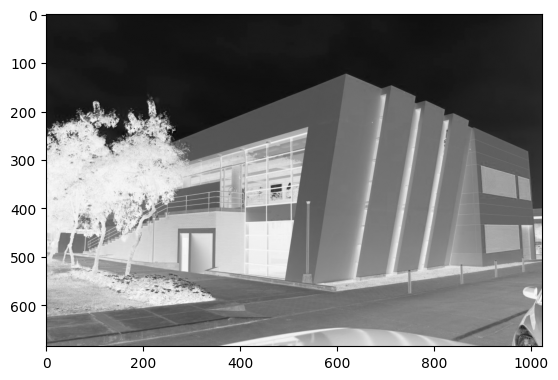

In [6]:
plt.imshow(aplicar(im, LUT), cmap='gray')

### Implementando una transformación de intensidad

Crear un algoritmo que tome 6 parámetros (corte1, corte2, vmin, v1, v2, vmax) y genere un LUT que sea básicamente la línea que conecta los siguientes puntos:

*   (0, vmin)
*   (corte1, v1)
*   (corte2, v2)
*   (255, vmax)

Recuerde que vmin puede ser mayor que vmax (como en el caso de la transformación que lleva de negativo -> positivo), sin embargo considere que 0 < corte1 < corte2 < 255, aunque no tiene que realizar ninguna validación.

Puede ver la función de transferencia en la imagen a continuación

**Recomendación** puede usar la función `np.linspace`.

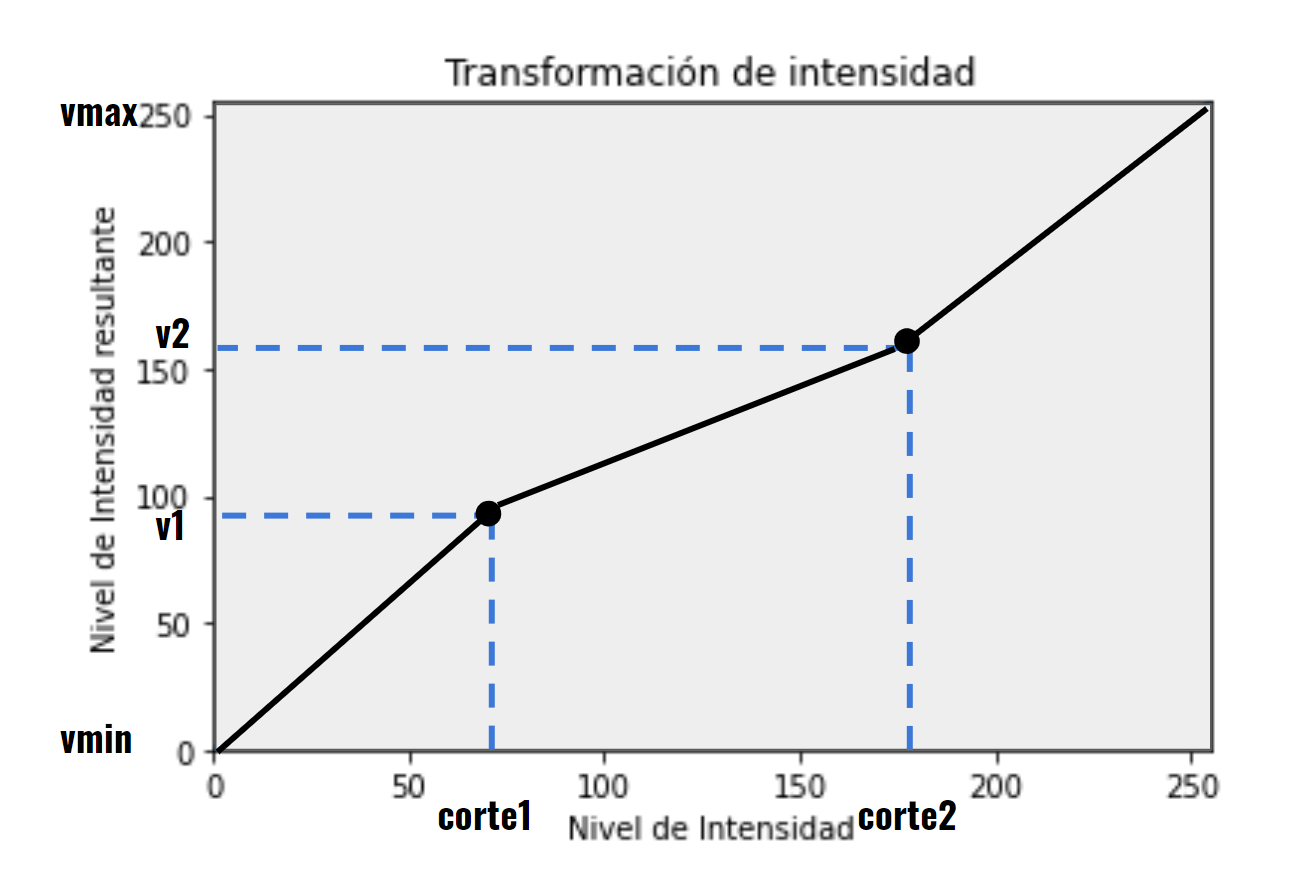




In [15]:
#@title Crear LUT { run: "auto" }
corte1 = 64 #@param {type:"slider", min:0, max:255, step:1}
corte2 = 131 #@param {type:"slider", min:0, max:255, step:1}
vmin = 93 #@param {type:"slider", min:0, max:255, step:1}
v1 = 7 #@param {type:"slider", min:0, max:255, step:1}
v2 = 77 #@param {type:"slider", min:0, max:255, step:1}
vmax = 27 #@param {type:"slider", min:0, max:255, step:1}
def generar_LUT(corte1, corte2, vmin, v1, v2, vmax):
    ########desarrollar aqui###############
    ## Puede asumir que 0 < corte1 < corte2 < 255

    LUT = np.concatenate([
                           np.linspace(vmin, v1, corte1),
                           np.linspace(v1, v2, corte2-corte1),
                           np.linspace(v2, vmax, 256-corte2)
                         ])

    ################################
    return LUT

A continuación, esta función puede mostrar la gráfica de función de transferencias de nuestra transformación

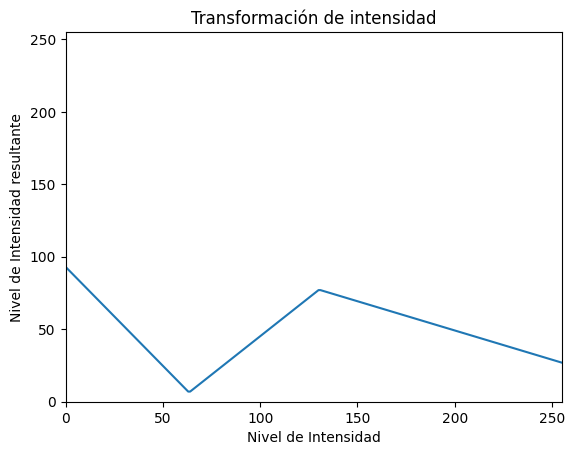

In [16]:
plt.figure()
plt.title("Transformación de intensidad")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Nivel de Intensidad")
plt.ylabel("Nivel de Intensidad resultante")
plt.plot(generar_LUT(corte1, corte2, vmin, v1, v2, vmax))

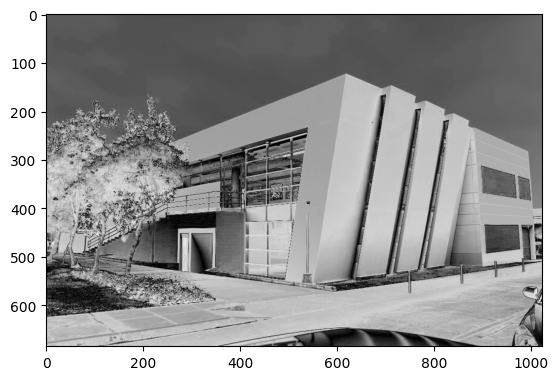

In [17]:
plt.imshow(aplicar(im, generar_LUT(corte1, corte2, vmin, v1, v2, vmax)), cmap='gray')

**Actividad de Clases**